##  PROMPT CHAINING WORKFLOW AI


In [33]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("GEMINI_API_KEY")

In [34]:
llm = ChatGoogleGenerativeAI(api_key=API_KEY, model="gemini-3.5-flash")
parser = StrOutputParser()
prompt = ChatPromptTemplate.from_messages([
    ('system', "Siz aqlli dastur yordamchisiz !"),
    ('human', "{user_request}")
])
chain = prompt | llm | parser

# for i in chain.stream({"user_request": "Salom siz qanday modelsiz!"}):
#     print(i.content[0],end="",flush=True)
print(chain.invoke({"user_request": 'Salom siz qanday modelsiz !'}))


Salom! Men Google tomonidan yaratilgan koʻp tilli katta til modeliman (nomim **Gemini**). 

Sizga dasturlash, matnlar yozish, tarjima qilish, savollarga javob berish va boshqa koʻplab intellektual vazifalarda yordam bera olaman. 

Bugun sizga qanday yordam bera olaman?


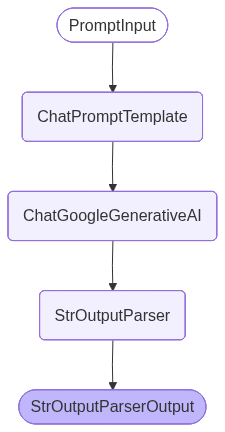

None


In [35]:
from IPython.display import display, Image

print(display(Image(chain.get_graph().draw_mermaid_png())))

## PARAlLELIZATION GRAPH AI


In [36]:
from typing import TypedDict, Annotated, List
from operator import add


class graph_schema(TypedDict):
    topic: str
    video_prompts: Annotated[List, add]
    image_prompts: Annotated[List, add]


In [37]:
def generate_prompt_video(state: graph_schema) -> graph_schema:
    topic = state['topic']
    prompt = ChatPromptTemplate.from_template(
        f"Menga shu {topic} mavzuda video uchun professional prompt yozib bering !")
    chain = prompt | llm | parser
    result = chain.invoke({
        "topic": topic,
    })
    return {"video_prompts": [result]}


def generate_prompt_image(state: graph_schema) -> graph_schema:
    topic = state['topic']
    prompt = ChatPromptTemplate.from_template(
        f"Menga shu {topic} mavzuda rasim uchun professional prompt yozib bering !")
    chain = prompt | llm | parser
    result = chain.invoke({
        "topic": topic,
    })
    return {"image_prompts": [result]}

In [38]:
from langgraph.graph import START, StateGraph, END

graph = StateGraph(graph_schema)

graph.add_node("generate_video_prompt", generate_prompt_video)
graph.add_node("generate_image_prompt", generate_prompt_image)

graph.add_edge(START, "generate_video_prompt")
graph.add_edge(START, "generate_image_prompt")

graph.add_edge("generate_video_prompt", END)
graph.add_edge("generate_image_prompt", END)

chain_graph = graph.compile()

response = chain_graph.invoke({
    "topic": "Yozgi tatil.",
    "video_prompts": [],
    "image_prompts": []
})
response

{'topic': 'Yozgi tatil.',
 'video_prompts': ['Yozgi ta\'til mavzusida video tayyorlash uchun sizga **ikki xil turdagi** professional promptni taqdim etaman. \n\n1. **AI (Sun\'iy intellekt: Sora, Runway, Pika, Midjourney) uchun ingliz tilidagi vizual promptlar** (chunki AI ingliz tilini yaxshi tushunadi).\n2. **Mobilograf yoki Videomontajchi uchun** batafsil ssenariy va kadrlar rejasi (O\'zbek tilida).\n\n---\n\n### 1-QISM: AI Video Generatorlar uchun Promptlar (Runway, Sora, Pika)\n\nBu promptlarni nusxalab, AI dasturlariga joylashtirishingiz mumkin.\n\n#### Variant A: Estetik va sokin yozgi ta\'til (Relaxing/Aesthetic)\n> **Prompt:** "Cinematic 4k drone shot of a pristine tropical beach during golden hour. Gentle turquoise waves crashing on soft white sand. A young woman in a summer dress walking along the shoreline, holding a straw hat. Sun rays filtering through palm trees, warm lighting, lens flare, highly detailed, photorealistic, 8k resolution, smooth camera movement."\n\n#### Va

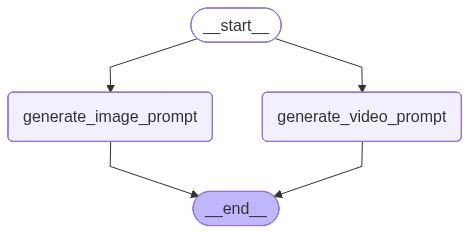

None


In [39]:
from IPython.display import display, Image

print(display(Image(chain_graph.get_graph().draw_mermaid_png())))